# Evaluation of K-Means Clustering Quality

This notebook evaluates K-Means clustering performance across project configurations using four complementary quality metrics and they include:

1. Silhouette Score
2. Davies-Bouldin Index
3. Cluster Compactness (within-cluster dispersion)
4. Cluster Separation (between-cluster dispersion)

All computed values are written to `results/metrics/clustering_summary.csv` and used for comparative visualization and reporting.

## Process Followed for Metric Evaluation

The project evaluation workflow is as follows.

### Step 1: Loading Existing Experiment Summary
Load the summary table from `results/metrics/clustering_summary.csv` to identify all clustering configurations that require evaluation.

### Step 2: Resolving Input Data for Each Configuration
For each configuration in the summary table:
- PCA configurations use their matching processed matrices (`X_pca_2.csv`, `X_pca_5.csv`, `X_pca_10.csv`).
- The sampled full-feature configuration uses `X_sample.csv`.
- Labels are not required for these unsupervised metrics, so `y_sample.csv` is intentionally not loaded in this notebook.

### Step 3: Refitting K-Means with Standardized Settings
Evaluate each configuration with fixed K-Means parameters (`n_clusters=2`, `init='k-means++'`, `random_state=42`, `n_init=20`) to preserve reproducibility.

### Step 4: Computing Clustering Quality Metrics
Compute four metrics for each fitted model:
- **Silhouette Score** for sample-level cohesion and separation.
- **Davies-Bouldin Index** for inter-cluster similarity (lower is better).
- **Compactness (WCSS)** for within-cluster dispersion.
- **Separation (BCSS)** for between-cluster dispersion.

### Step 5: Runtime and Integrity Safeguards
The computation includes the following safeguards:
- Silhouette uses sampling on large datasets to reduce runtime and memory pressure.
- Missing data files are skipped with explicit warnings.
- Rows labeled as full-dataset runs are not silently evaluated on sampled matrices.
- Summary `n_rows` metadata is checked against loaded matrix length.

### Step 6: Updating the Consolidated Summary File
Write computed metrics back to their corresponding rows in `clustering_summary.csv` to maintain a single project-wide results table.

### Step 7: Generating Visual Outputs for Comparative Analysis
Produce two report outputs:
- A multi-panel comparison plot across the PCA dimensions.
- A summary table of the computed metrics.

### Step 8: Interpreting Results
Interpret all four metrics jointly, favoring configurations with higher Silhouette and Separation and lower Davies-Bouldin and Compactness.

## Import Required Libraries

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

warnings.filterwarnings('ignore')

## Define Metric Functions

In [2]:
def calculate_compactness(X, labels, centroids):
    """Compute average within-cluster sum of squares (WCSS)."""
    wcss = 0.0
    for cluster_id in np.unique(labels):
        cluster_points = X[labels == cluster_id]
        centroid = centroids[cluster_id]
        wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss / len(X)


def calculate_separation(X, labels, centroids):
    """Compute average between-cluster sum of squares (BCSS)."""
    global_centroid = np.mean(X, axis=0)
    bcss = 0.0

    for cluster_id in np.unique(labels):
        cluster_size = np.sum(labels == cluster_id)
        centroid = centroids[cluster_id]
        bcss += cluster_size * np.sum((centroid - global_centroid) ** 2)

    return bcss / len(X)

## Load Project Paths and Existing Summary

In [3]:
project_root = Path.cwd()
if not (project_root / 'data' / 'processed').exists() and (project_root.parent / 'data' / 'processed').exists():
    project_root = project_root.parent

processed_dir = project_root / 'data' / 'processed'
summary_path = project_root / 'results' / 'metrics' / 'clustering_summary.csv'

if summary_path.exists():
    df_summary = pd.read_csv(summary_path)
else:
    raise FileNotFoundError(f"Missing summary file: {summary_path}")

## Compute Metrics for Each Clustering Configuration

### Amendment Summary

- **Silhouette scalability:** use sampled silhouette on large matrices (`sample_size`, `random_state`).
- **No unnecessary label I/O:** `y_sample.csv` is not loaded in this unsupervised metric loop.
- **Full-vs-sample guard:** rows tagged as full runs are not evaluated on sampled feature matrices.
- **Stable dataset identifiers:** `dataset_version` remains unchanged; evaluation notes are stored in `quality_metrics_status`.

In [4]:
metrics_results = {}

SILHOUETTE_SAMPLE_THRESHOLD = 100_000
SILHOUETTE_SAMPLE_SIZE = 50_000

for _, row in df_summary.iterrows():
    method = row['method']
    dataset_version = row['dataset_version']
    n_clusters = int(row['n_clusters'])

    # Guardrail: do not accidentally evaluate the "full" row on sampled data.
    if 'PCA' not in method and 'full' in str(dataset_version).lower():
        print(
            f"Skipped metric computation for {method} ({dataset_version}): "
            "full-dataset feature matrix is not evaluated in this notebook."
        )
        metrics_results[(method, dataset_version)] = {
            'silhouette_score': np.nan,
            'davies_bouldin': np.nan,
            'compactness': np.nan,
            'separation': np.nan,
            'quality_metrics_status': 'not_evaluated_due_to_scale',
        }
        continue

    if 'PCA' in method:
        n_components = int(method.split()[-1])
        data_file = processed_dir / f'X_pca_{n_components}.csv'
    else:
        data_file = processed_dir / 'X_sample.csv'

    if not data_file.exists():
        print(f"Skipped: missing feature file {data_file}")
        metrics_results[(method, dataset_version)] = {
            'silhouette_score': np.nan,
            'davies_bouldin': np.nan,
            'compactness': np.nan,
            'separation': np.nan,
            'quality_metrics_status': 'not_evaluated_missing_file',
        }
        continue

    X = pd.read_csv(data_file).values

    # Optional sanity check against metadata table row count.
    if 'n_rows' in row and pd.notna(row['n_rows']) and int(row['n_rows']) != len(X):
        print(
            f"Warning: n_rows mismatch for {method} ({dataset_version}) - "
            f"summary={int(row['n_rows'])}, loaded={len(X)}"
        )

    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_

    # Silhouette can be very expensive on large datasets, so sample when needed.
    silhouette_sampled = len(X) > SILHOUETTE_SAMPLE_THRESHOLD
    if silhouette_sampled:
        silhouette = silhouette_score(
            X,
            labels,
            sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X)),
            random_state=42,
        )
        quality_status = 'evaluated_sampled_silhouette'
    else:
        silhouette = silhouette_score(X, labels)
        quality_status = 'evaluated_full_silhouette'

    davies_bouldin = davies_bouldin_score(X, labels)
    compactness = calculate_compactness(X, labels, centroids)
    separation = calculate_separation(X, labels, centroids)

    metrics_results[(method, dataset_version)] = {
        'silhouette_score': silhouette,
        'davies_bouldin': davies_bouldin,
        'compactness': compactness,
        'separation': separation,
        'quality_metrics_status': quality_status,
    }

print(f"Computed metrics for {len(metrics_results)} configurations.")

Skipped metric computation for KMeans Full 28 (HIGGS.csv.gz(full)): full-dataset feature matrix is not evaluated in this notebook.
Skipped metric computation for KMeans Full 28 (HIGGS.csv.gz(full)): full-dataset feature matrix is not evaluated in this notebook.
Computed metrics for 5 configurations.


## Update Summary Table and Save Results

In [5]:
if 'quality_metrics_status' not in df_summary.columns:
    df_summary['quality_metrics_status'] = pd.Series([None] * len(df_summary), dtype='object')
else:
    df_summary['quality_metrics_status'] = df_summary['quality_metrics_status'].astype('object')

for idx, row in df_summary.iterrows():
    key = (row['method'], row['dataset_version'])
    if key in metrics_results:
        df_summary.at[idx, 'silhouette_score'] = metrics_results[key]['silhouette_score']
        df_summary.at[idx, 'davies_bouldin'] = metrics_results[key]['davies_bouldin']
        df_summary.at[idx, 'compactness'] = metrics_results[key]['compactness']
        df_summary.at[idx, 'separation'] = metrics_results[key]['separation']
        df_summary.at[idx, 'quality_metrics_status'] = metrics_results[key]['quality_metrics_status']

df_summary.to_csv(summary_path, index=False)
print(f"Saved updated metrics to: {summary_path}")

Saved updated metrics to: c:\Users\austi\Desktop\Code\CS4630\CS4630_Group3_Project2\results\metrics\clustering_summary.csv


## Generate Comparative Visualizations

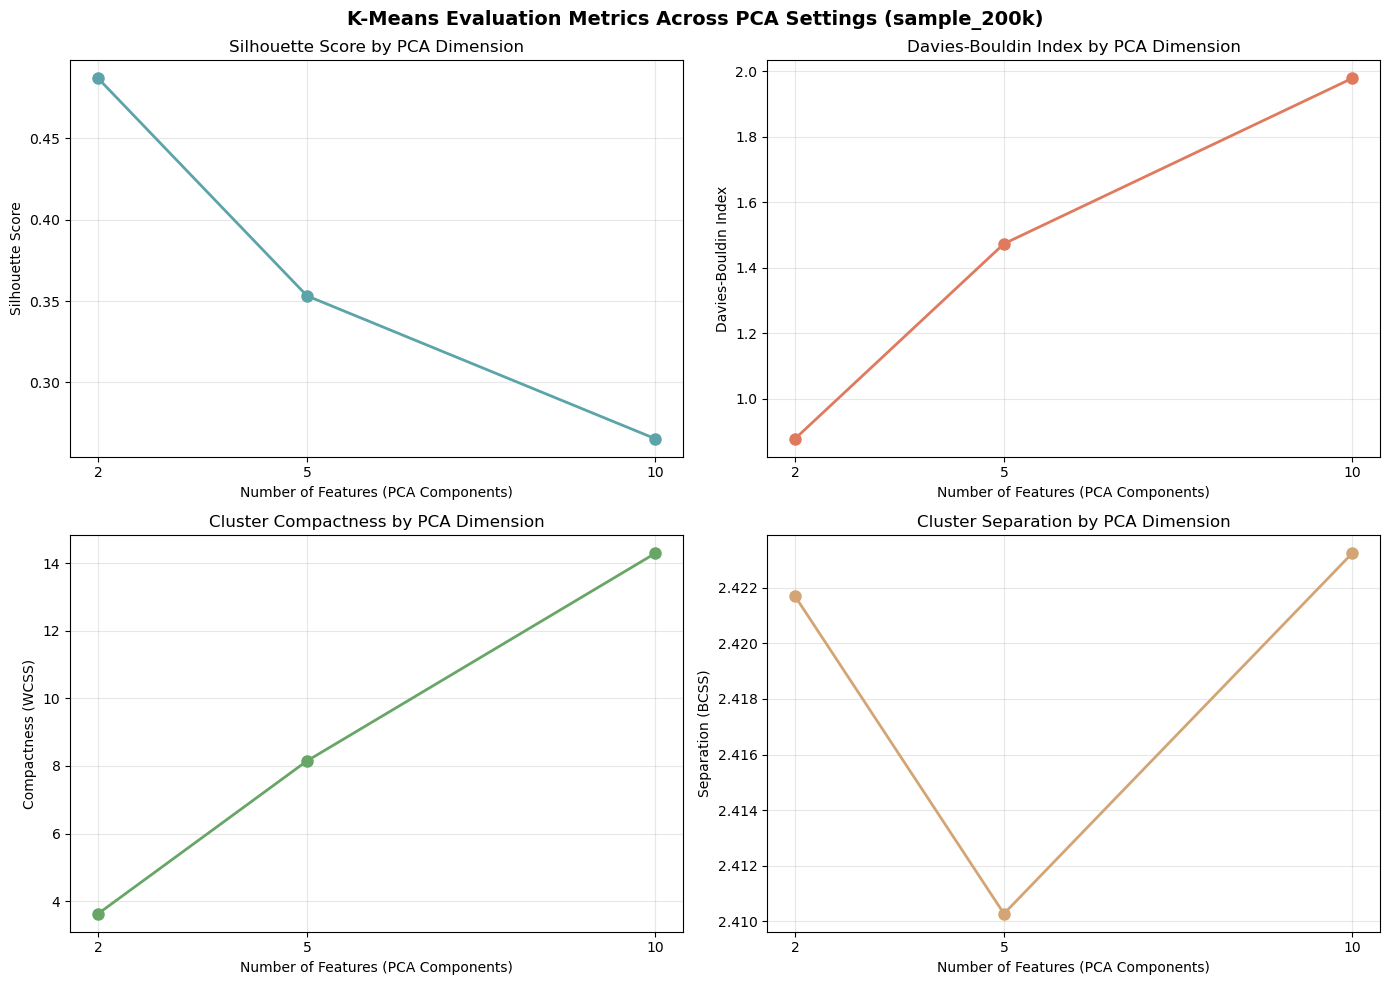

In [6]:
viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

pca_methods = df_summary[
    (df_summary['method'].str.contains('PCA', na=False))
    & (df_summary['dataset_version'] == 'sample_200k')
].copy().sort_values('n_features')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(pca_methods['n_features'], pca_methods['silhouette_score'], 'o-', color='#5ca4a9', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features (PCA Components)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score by PCA Dimension')
ax.grid(True, alpha=0.3)
ax.set_xticks(pca_methods['n_features'].values)

ax = axes[0, 1]
ax.plot(pca_methods['n_features'], pca_methods['davies_bouldin'], 'o-', color='#e07a5f', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features (PCA Components)')
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index by PCA Dimension')
ax.grid(True, alpha=0.3)
ax.set_xticks(pca_methods['n_features'].values)

ax = axes[1, 0]
ax.plot(pca_methods['n_features'], pca_methods['compactness'], 'o-', color='#67a667', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features (PCA Components)')
ax.set_ylabel('Compactness (WCSS)')
ax.set_title('Cluster Compactness by PCA Dimension')
ax.grid(True, alpha=0.3)
ax.set_xticks(pca_methods['n_features'].values)

ax = axes[1, 1]
ax.plot(pca_methods['n_features'], pca_methods['separation'], 'o-', color='#d4a574', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features (PCA Components)')
ax.set_ylabel('Separation (BCSS)')
ax.set_title('Cluster Separation by PCA Dimension')
ax.grid(True, alpha=0.3)
ax.set_xticks(pca_methods['n_features'].values)

fig.suptitle('K-Means Evaluation Metrics Across PCA Settings (sample_200k)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(viz_dir / 'clustering_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

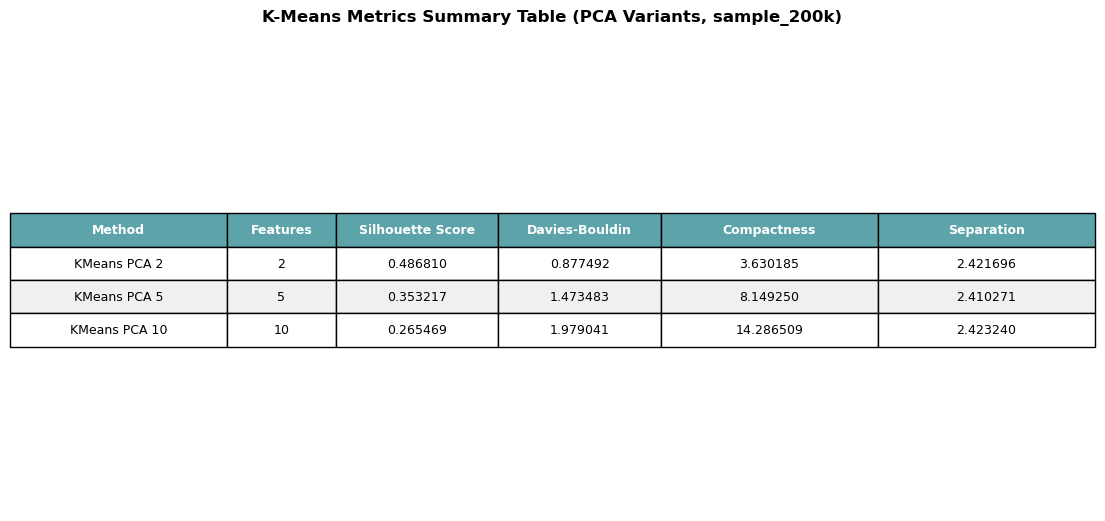

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

table_data = pca_methods[
    ['method', 'n_features', 'silhouette_score', 'davies_bouldin', 'compactness', 'separation']
].copy()
table_data.columns = ['Method', 'Features', 'Silhouette Score', 'Davies-Bouldin', 'Compactness', 'Separation']

for col in ['Silhouette Score', 'Davies-Bouldin', 'Compactness', 'Separation']:
    table_data[col] = table_data[col].apply(lambda x: f'{x:.6f}')

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.1, 0.15, 0.15, 0.2, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(len(table_data.columns)):
    table[(0, i)].set_facecolor('#5ca4a9')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(table_data) + 1):
    for j in range(len(table_data.columns)):
        table[(i, j)].set_facecolor('#f0f0f0' if i % 2 == 0 else '#ffffff')

plt.title('K-Means Metrics Summary Table (PCA Variants, sample_200k)', fontsize=12, fontweight='bold', pad=20)
plt.savefig(viz_dir / 'metrics_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()